In [1]:
import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch

import src.utils as utils
import src.visuals as visual

from src.models import PINN
from src.dataloader import load_data

import os
import tempfile

from PIL import Image
from IPython.display import Image as IPImage, display



In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

TRAIN_DATA_PATH = pathlib.Path("data/sampled_data/frac_1")
TRAIN_FILE_NAME = "data"

TEST_DATA_PATH = pathlib.Path("data/raw_data")
TEST_FILE_NAME = "data"

RUNS_DIR = pathlib.Path("heldout_runs")

INPUT_COL_NAMES = ["time", "re", "x", "y"]
TARGET_COL_NAMES = ["U_x", "U_y", "p"]

# Held-out box koji vizualizujemo (mora se poklapati sa boxom u treniranim run-ovima).
# [0.1, 0.9] = najveci izbaceni region (64% povrsine) -> najjasniji kontrast fizika/bez fizike.
BOX = {"x_min": 0.1, "x_max": 0.9, "y_min": 0.1, "y_max": 0.9}

RE_INDEX = 4      # koji Re iz test skupa (po redu sortiranih vrijednosti)
TIME_STEP = 5.0   # vremenski trenutak

Device: cpu


In [3]:
def boxes_equal(a, b, tol=1e-9):
    return all(abs(a[k] - b[k]) < tol for k in ("x_min", "x_max", "y_min", "y_max"))

candidates = []

for run in sorted(RUNS_DIR.iterdir()):
    cfg_path = run / "config.json"
    metr_path = run / "metrics.csv"

    if not cfg_path.exists() or not metr_path.exists():
        continue

    cfg = json.load(open(cfg_path))

    if "box" not in cfg or not boxes_equal(cfg["box"], BOX):
        continue

    metrics = pd.read_csv(metr_path)
    inside = metrics[metrics["region"] == "inside_box"].iloc[0]

    candidates.append({
        "run": run,
        "c_physics": cfg["physics_weight"],
        "R2_inside": float(inside["R2_all"]),
        "RelL2_inside": float(inside["RelL2_all"]),
    })

cand_df = (
    pd.DataFrame([{k: v for k, v in c.items() if k != "run"} for c in candidates])
    .sort_values("c_physics")
    .reset_index(drop=True)
)

print(f"Box {BOX} -> {len(candidates)} treniranih modela")
display(cand_df)

Box {'x_min': 0.1, 'x_max': 0.9, 'y_min': 0.1, 'y_max': 0.9} -> 6 treniranih modela


,c_physics,R2_inside,RelL2_inside
0,0.00,0.456512,0.724744
1,0.01,0.433244,0.740095
2,0.05,0.422724,0.746933
3,0.10,0.454808,0.725879
4,0.50,0.527370,0.675850
5,1.00,0.602834,0.619549


In [4]:
# Bez fizike = c_physics == 0. Najbolji sa fizikom = max R2 u izbacenom regionu (c_physics > 0).
no_phys = next(c for c in candidates if c["c_physics"] == 0.0)
best_phys = max((c for c in candidates if c["c_physics"] > 0.0), key=lambda c: c["R2_inside"])

print(f"Bez fizike:     {no_phys['run'].name}")
print(f"  c_physics={no_phys['c_physics']}, R2_inside={no_phys['R2_inside']:.4f}")
print(f"\nPINN (fizika):  {best_phys['run'].name}")
print(f"  c_physics={best_phys['c_physics']}, R2_inside={best_phys['R2_inside']:.4f}")

Bez fizike:     2026-07-10_17-36-02_heldout_cphys_0
  c_physics=0.0, R2_inside=0.4565

PINN (fizika):  2026-07-10_17-49-06_heldout_cphys_1
  c_physics=1.0, R2_inside=0.6028


In [15]:
train_df, _, _ = load_data(TRAIN_DATA_PATH, TRAIN_FILE_NAME)
_, train_out = utils.split_by_box(train_df, BOX)

mean = train_out.mean()
std = train_out.std()


def load_pinn(run_dir):
    model = PINN(len(INPUT_COL_NAMES), len(TARGET_COL_NAMES)).to(device)
    ckpt = torch.load(run_dir / "best_model.pth", map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


model_phys = load_pinn(best_phys["run"])
model_nophys = load_pinn(no_phys["run"])

print("Modeli ucitani.")

Modeli ucitani.


In [6]:
_, _, test_df = load_data(TEST_DATA_PATH, TEST_FILE_NAME)

# Sortiranje je NEOPHODNO za reshape u src/visuals.py (y-major, x-minor).
test_df = test_df.sort_values(["re", "time", "y", "x"]).reset_index(drop=True)

re_values = sorted(test_df["re"].unique())
RE_VALUE = re_values[RE_INDEX]

print(f"Dostupni Re: {[round(r, 1) for r in re_values]}")
print(f"Odabrano:    Re = {RE_VALUE:.2f}, t = {TIME_STEP}")

# Puno stanje (bez izbacenih tacaka) = ground truth
state = test_df[(test_df["re"] == RE_VALUE) & (test_df["time"] == TIME_STEP)].copy()
print(f"Tacaka u stanju: {len(state)}")

Dostupni Re: [np.float64(118.4), np.float64(228.6), np.float64(320.4), np.float64(430.6), np.float64(559.2), np.float64(669.4), np.float64(853.1), np.float64(889.8)]
Odabrano:    Re = 559.18, t = 5.0
Tacaka u stanju: 16384


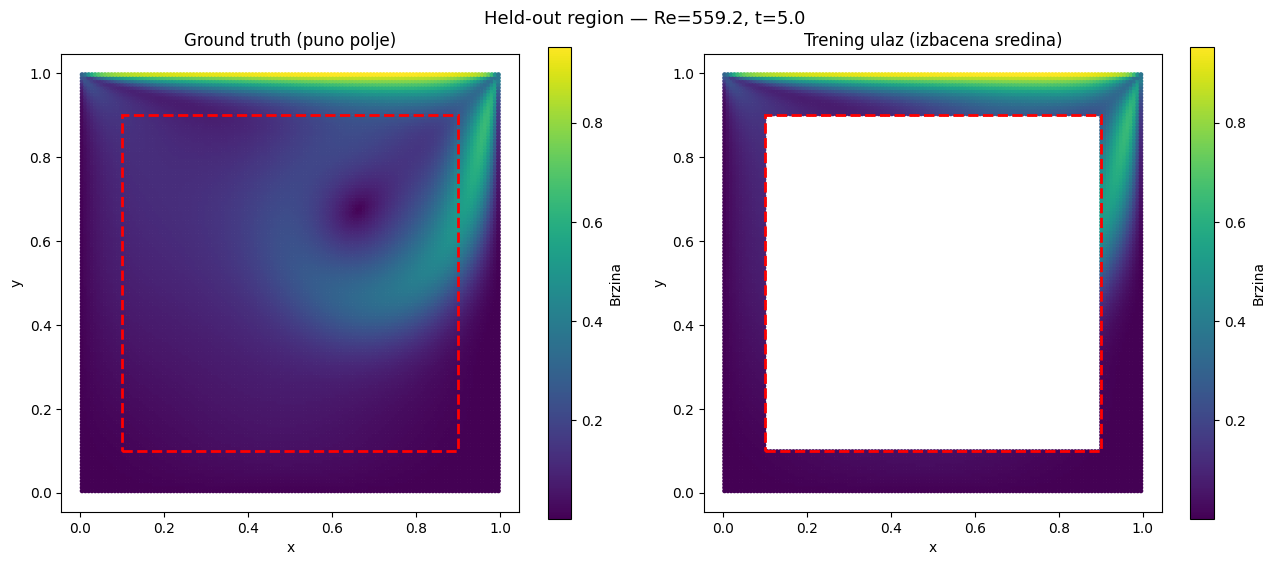

In [7]:
inside_pts, outside_pts = utils.split_by_box(state, BOX)

speed_all = np.sqrt(state["U_x"] ** 2 + state["U_y"] ** 2)
vmin, vmax = float(speed_all.min()), float(speed_all.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (d, title) in zip(
    axes,
    [(state, "Ground truth (puno polje)"),
     (outside_pts, "Trening ulaz (izbacena sredina)")],
):
    speed = np.sqrt(d["U_x"] ** 2 + d["U_y"] ** 2)
    sc = ax.scatter(d["x"], d["y"], c=speed, s=6, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.add_patch(patches.Rectangle(
        (BOX["x_min"], BOX["y_min"]),
        BOX["x_max"] - BOX["x_min"], BOX["y_max"] - BOX["y_min"],
        fill=False, edgecolor="red", linewidth=2, linestyle="--",
    ))
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="Brzina")

fig.suptitle(f"Held-out region — Re={RE_VALUE:.1f}, t={TIME_STEP}", fontsize=13)
plt.tight_layout()
plt.show()

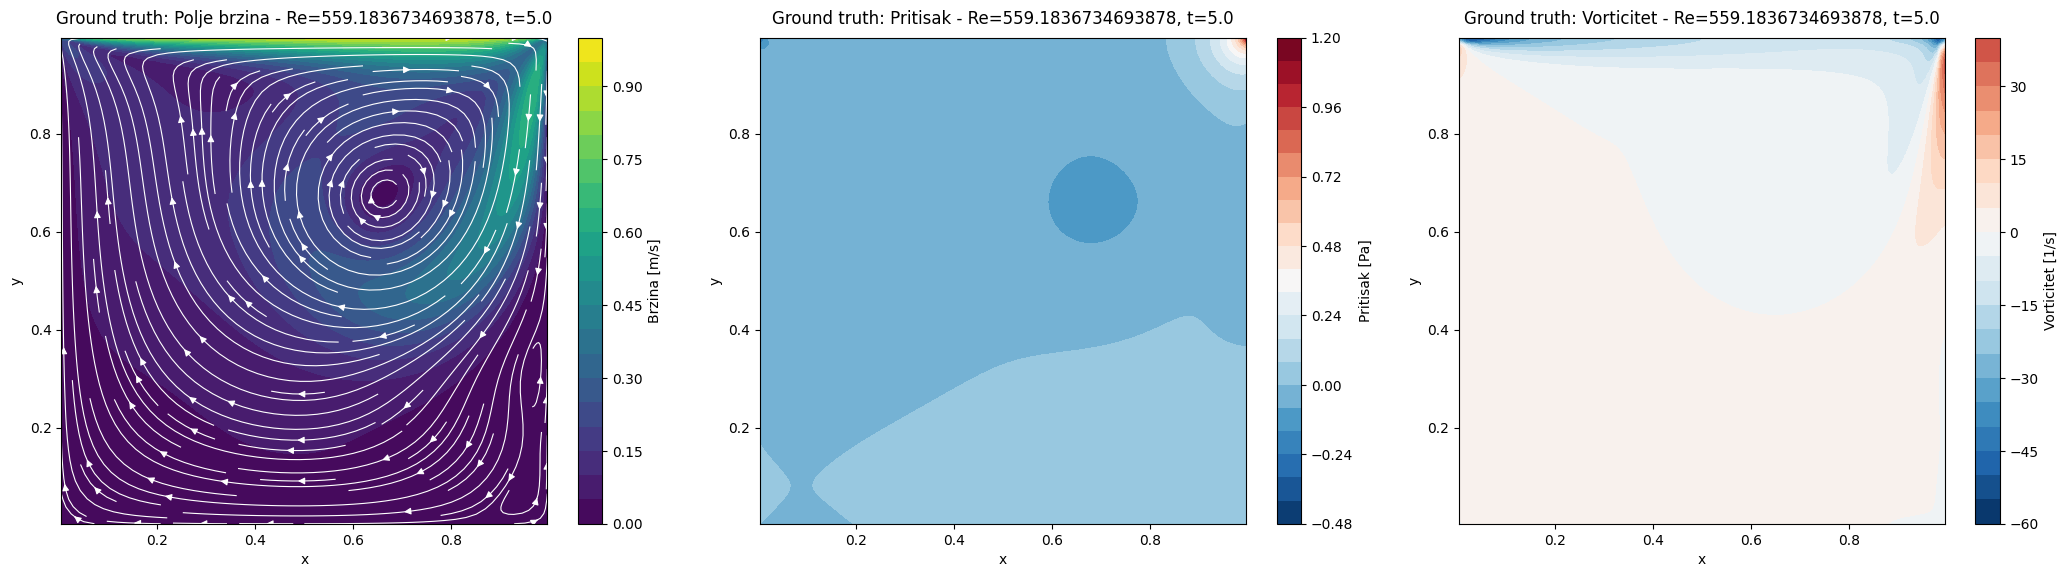

In [8]:
visual.plot_velocity_and_pressure(test_df, TIME_STEP, RE_VALUE, "Ground truth:")

In [9]:
pred_phys = utils.predict_field(model_phys,INPUT_COL_NAMES, TARGET_COL_NAMES, state, mean, std, device)
pred_nophys = utils.predict_field(model_nophys,INPUT_COL_NAMES, TARGET_COL_NAMES, state, mean, std, device)

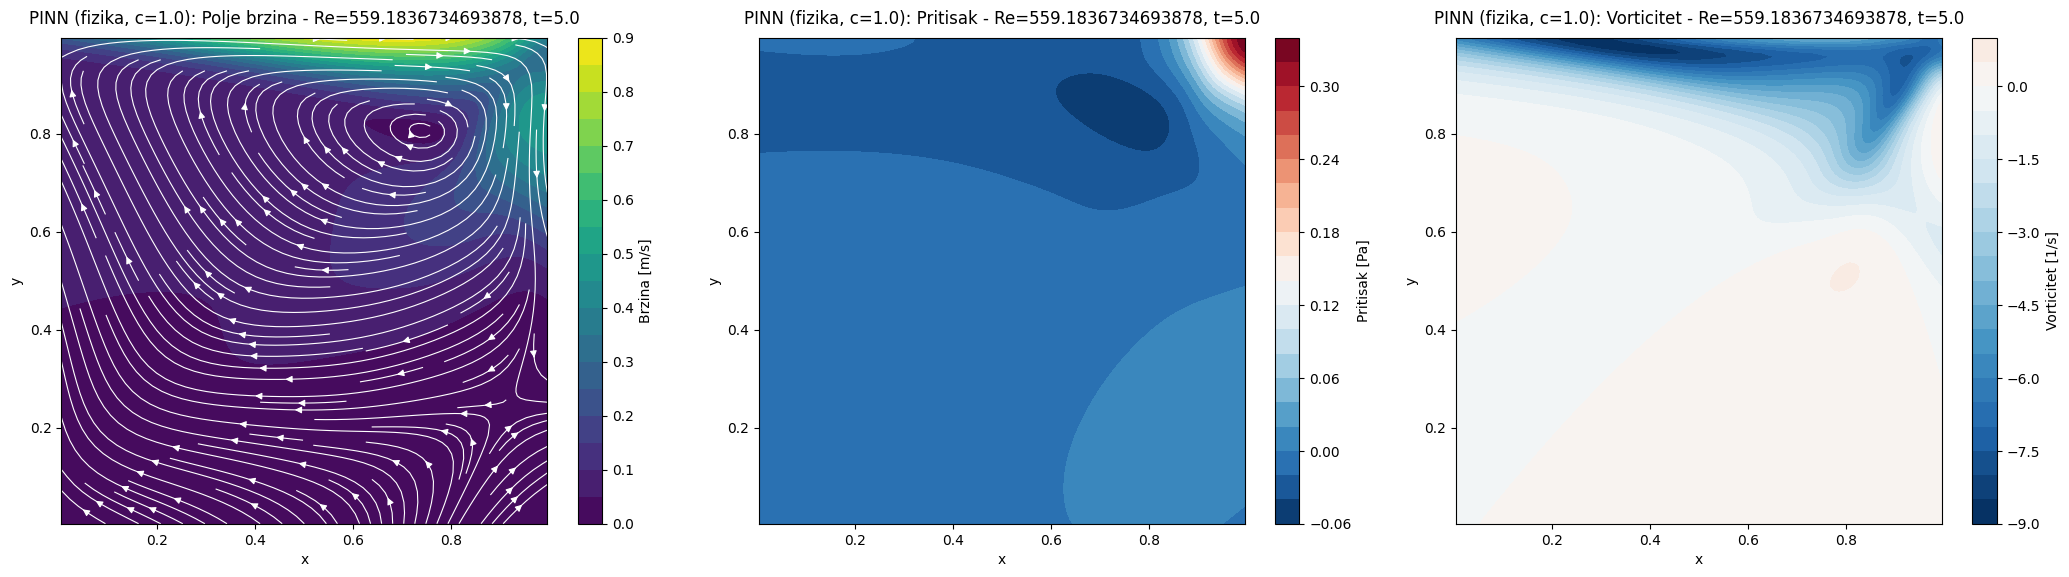

In [10]:
visual.plot_velocity_and_pressure(
    pred_phys, TIME_STEP, RE_VALUE, f"PINN (fizika, c={best_phys['c_physics']}):"
)

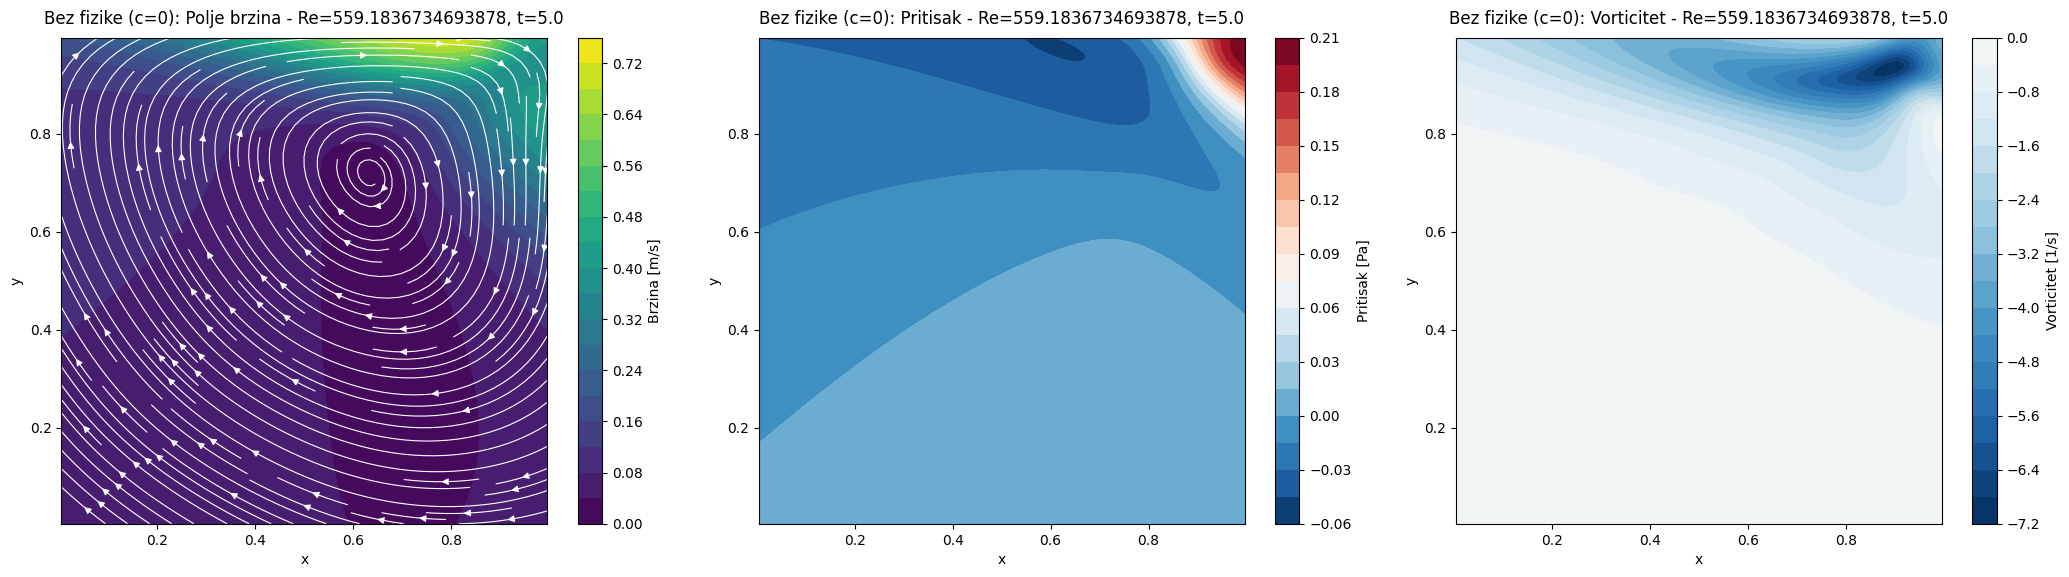

In [11]:
visual.plot_velocity_and_pressure(
    pred_nophys, TIME_STEP, RE_VALUE, "Bez fizike (c=0):"
)

=== PINN (fizika, c=1.0) ===
MAE U_x: 0.049376
MAE U_y: 0.048197
MAE p:   0.009945


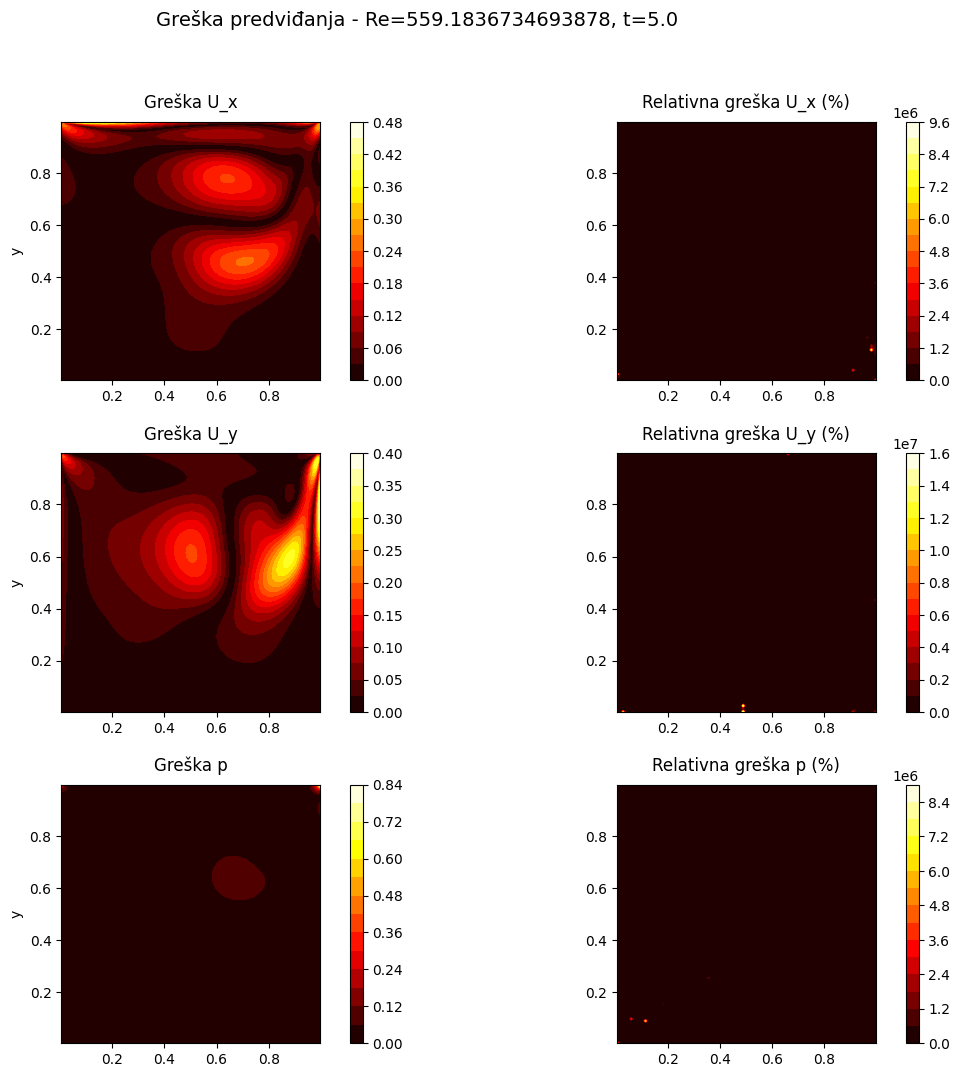

In [12]:
print("=== PINN (fizika, c={}) ===".format(best_phys["c_physics"]))
visual.compare_predictions(model_phys, test_df, TIME_STEP, RE_VALUE, mean, std, device)

=== Bez fizike (c=0) ===
MAE U_x: 0.060969
MAE U_y: 0.051916
MAE p:   0.014004


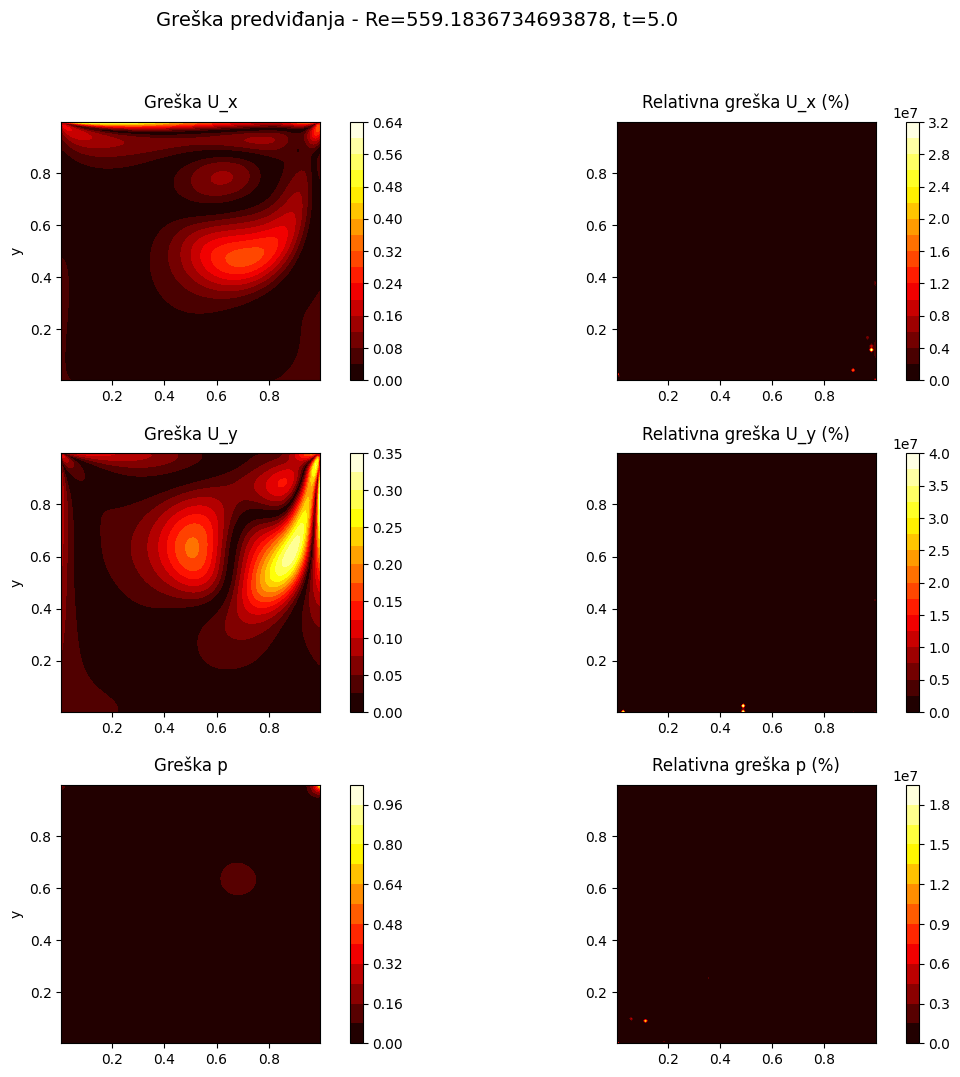

In [13]:
print("=== Bez fizike (c=0) ===")
visual.compare_predictions(model_nophys, test_df, TIME_STEP, RE_VALUE, mean, std, device)

In [14]:
def inside_box_metrics(model, state, box):
    inside_pts, _ = utils.split_by_box(state, box)
    m = utils.evaluate_model(
        model, inside_pts, INPUT_COL_NAMES, TARGET_COL_NAMES, mean, std, device
    )
    return m["all"]


rows = []
for name, model in [
    ("Bez fizike (c=0)", model_nophys),
    (f"PINN (fizika, c={best_phys['c_physics']})", model_phys),
]:
    m = inside_box_metrics(model, state, BOX)
    rows.append({"model": name, **{k: m[k] for k in ["R2", "MAE", "RMSE", "RelL2"]}})

print(f"Izbaceni region, Re={RE_VALUE:.1f}, t={TIME_STEP}")
display(pd.DataFrame(rows))

Izbaceni region, Re=559.2, t=5.0


,model,R2,MAE,RMSE,RelL2
0,Bez fizike (c=0),0.449120,0.043850,0.071870,0.730468
1,"PINN (fizika, c=1.0)",0.516486,0.041955,0.067333,0.684349


In [ ]:
# Gust dataset (Re=550, 286 vremenskih koraka)
ANIM_DF = pd.read_csv("data/re550_animation.csv")
ANIM_DF = ANIM_DF.sort_values(["re", "time", "y", "x"]).reset_index(drop=True)
ANIM_RE = 550

# (opciono) prorijedi vremenske korake radi brzine/velicine GIF-a: TIME_STRIDE > 1
TIME_STRIDE = 1
keep_times = sorted(ANIM_DF["time"].unique())[::TIME_STRIDE]
ANIM_DF = ANIM_DF[ANIM_DF["time"].isin(keep_times)]

ANIM_OUT = pathlib.Path("results/heldout_all_components_anim.gif")
ANIM_OUT.parent.mkdir(parents=True, exist_ok=True)

ANIM_OUT = visual.animate_flow_tmp(
    ANIM_OUT, BOX, ANIM_DF, ANIM_RE,
    model_phys, model_nophys, best_phys["c_physics"], mean, std, device,
)

print(f"GIF spreman: {ANIM_OUT}")
display(IPImage(str(ANIM_OUT)))

Generiši 286 frame-ova (fps=28.57 iz config/sampling/animation.yaml)...
  ✓ 57/286 frame-ova generirano
  ✓ 114/286 frame-ova generirano
  ✓ 171/286 frame-ova generirano
